<a href="https://colab.research.google.com/github/BMClab/h2a_age_spt/blob/main/notebooks/h2a_age_spt_comf_speed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A test of the joint torque redistribution hypothesis

> [Laboratory of Biomechanics and Motor Control](https://bmclab.pesquisa.ufabc.edu.br/)  
> Federal University of ABC, Brazil

## Introduction

This notebook reports the statistical results of testing two hypotheses:  
1. Aging is associated to a redistribution of joint torques and powers during gait (proposed by DeVita and Hortobagyi in 2000).  
2. Age-group associations with kinetic ratios change when step length or cadence is included as a continuous covariate. These models assess associations and do not establish a causal mechanism.

The experimental data are taken from an open dataset (Fukuchi et al., 2018). This dataset contains raw and processed data from standard 3d gait analysis of healthy volunteers walking in both overground and treadmill in a range of speeds.  

The current analysis compares young and older adults using one selected V4, V5, or V6 trial per participant at similar absolute speeds (1.12–1.32 m/s). These selected trials are not necessarily each participant's preferred-speed trial. The exact upstream selection rule remains pending verification; the filename does not establish that all trials were collected at individual comfortable speeds.

The original manuscript describes discrete kinetic measures motivated by DeVita and Hortobagyi (2000). Exact preprocessing and integration details require verification against the upstream calculation script.  

## Python setup

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.stats.api as sms
from tqdm import tqdm

if "google.colab" in sys.modules:
    %pip install -q pingouin
    %pip install -q watermark

import pingouin as pg

%load_ext watermark

### Environment

In [2]:
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.1)
#palette = sns.color_palette(palette='Set1')  # tab10
#palette[0], palette[1] = palette[1], palette[0]
#sns.set_palette(palette=palette)
pd.set_option('display.precision', 3)  # number of decimal places for the environment
#pd.set_option('future.no_silent_downcasting', True)

# significance level
alpha = 0.05
# colors
#colors = sns.color_palette()
colors = plotly.colors.DEFAULT_PLOTLY_COLORS
colors2 = [tuple(np.fromstring(c[4:-1], sep=',')/255) for c in colors]

%watermark -u -t -d -m -v --iversions

Last updated: 2026-09-11 00:28:18

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.16.1

Compiler    : Clang 22.1.3 
OS          : Linux
Release     : 7.0.0-31-generic
Machine     : x86_64
Processor   : 
CPU cores   : 16
Architecture: 64bit

matplotlib : 3.11.1
numpy      : 2.5.2
pandas     : 3.0.5
pingouin   : 0.6.1
plotly     : 6.9.0
seaborn    : 0.13.2
statsmodels: 0.14.6
tqdm       : 4.70.0



### Custom functions

In [3]:
def ttest(df, feature, group, levels=None, alpha=alpha):
    """Welch/independent t statistics with signed Cohen d: levels[0] minus levels[1].

    Explicit Older, Young calls report Older minus Young for d and percent difference.
    """
    stats = []
    if levels is None:
        levels = df[group].unique()
    if len(levels) != 2:
        raise Exception('Incorrect number of levels: {}'.format(len(levels)))
    for f in feature:
        x = df[df[group] == levels[0]][f]
        y = df[df[group] == levels[1]][f]
        stat = pg.ttest(x, y, confidence=1-alpha)
        # Pingouin reports absolute Cohen d; use the table's stated group direction.
        pooled_sd = np.sqrt(((len(x)-1)*x.var(ddof=1) + (len(y)-1)*y.var(ddof=1))
                            / (len(x)+len(y)-2))
        stat['cohen_d'] = (x.mean() - y.mean()) / pooled_sd
        stat.index = [f]
        diff = np.round(100 * (np.mean(x) - np.mean(y)) / np.mean(y), decimals=1)
        diff = pd.DataFrame(data=diff, index=[f], columns=['%diff'], dtype=float)
        stat = pd.concat([stat, diff], axis=1)
        stats.append(stat)

    stats = [df.dropna(axis=1, how='all') for df in stats]
    stats = pd.concat(stats, axis=0)
    stats.drop(columns=['alternative', 'BF10', 'power'], inplace=True)
    stats.index.name = '{} minus {} (signed d)'.format(*levels)
    display(stats.style.format({'p_val': '{:.3f}'}).apply(sig_red, subset='p_val', axis=1))
    return stats


def normtest(df, feature, group, alpha=alpha):
    """Normality test for dataframe columns using the pingouin library.
    """
    levels = df[group].unique()
    for level in levels:
        test = pg.normality(df[df[group] == level][feature], method='normaltest')
        test.index.name = level
        display(test.style.format({'pval': '{:.3f}'}).apply(sig_red, axis=1))


def normality(df):
    """Get the p-val of the normality test using the pingouin library.
    """
    return pg.normality(df)['pval']


def describe(df, feature, group, stat=['count', 'mean', 'std', 'min', 'max', normality]):
    """Descriptive statistics for dataframe columns.
    """
    col = [('Young', 'normality'), ('Older', 'normality')]
    x = df.groupby(group)[feature].agg(stat).stack(future_stack=True).transpose().style.apply(sig_red, subset=col)
    display(x)
    return x


def sig_red(col, alpha=alpha):
    """Returns string 'color: red' for `col` < `alpha`, black otherwise.
    """
    col = np.array([(float(x.lstrip('<').strip()) if isinstance(x, str) else float(x))
                    if len(str(x)) else np.nan for x in col])

    is_sig = col < alpha
    return ['color: red' if x else 'color: black' for x in is_sig]


def regression(fit_ml, fit_re, names):
    """Get results from linear regression as list.

    results = ['Response', 'Coef', 'CI', 'p', 'Coef', 'CI', 'p', Coef', 'CI', 'p',
               'llf', 'AIC', 'R2']
    """
    # print(fit_re.model.exog_names)
    if names is None:
        names = fit_re.model.exog_names[1:]
    results = [np.nan]*(1 + len(names)*3 + 3)
    # response
    results[ 0] = fit_re.model.endog_names
    # log-likelihood function
    results[-3] = '{:.1f}'.format(fit_ml.llf)
    # Akaike information criterion
    results[-2] = '{:.1f}'.format(fit_ml.aic)
    # marginal R2, proportion of variance explained by the fixed factor(s) alone
    results[-1] = '{:.2f}'.format(np.corrcoef(fit_re.model.endog, fit_re.predict())[0, 1]**2)
    # conditional R2, proportion of variance explained by both the fixed and random factors
    #results[-1] = np.round(np.corrcoef(fit_re.model.endog, fit_re.fittedvalues)[0, 1]**2, 2)
    for name in fit_re.model.exog_names[1:]:
        idx = names.index(name)
        # fitted fixed-effects coefficients
        results[3*idx+1] = '{:.2f}'.format(fit_re.params[name])
        # confidence interval for the fitted parameters
        ci = fit_re.conf_int().loc[name].values
        results[3*idx+2] = '[{:.2f}, {:.2f}]'.format(ci[0], ci[1])
        # two-tailed p values for the t-stats of the params
        if fit_re.pvalues[name] < 0.0001:
            results[3*idx+3] = '< 0.0001'
        else:
            results[3*idx+3] = '{:.4f}'.format(fit_re.pvalues[name])

    return results


def runmodels(data, predictors, responses, groups, names, mixed=True, show=True):
    """Fit mixed models separately by ML/REML, or OLS once per formula."""
    fit_ml, fit_re, models = [], [], []
    for response in responses:
        for predictor in predictors:
            eq = f'{response} ~ {predictor}'
            if mixed:
                # Distinct model objects: MixedLM.fit mutates the model REML flag.
                ml = smf.mixedlm(eq, data, groups=groups).fit(reml=False)
                re = smf.mixedlm(eq, data, groups=groups).fit(reml=True)
                assert ml.converged and re.converged, f'Nonconverged: {eq}'
            else:
                ml = re = smf.ols(eq, data).fit()
            fit_ml.append(ml)
            fit_re.append(re)
            models.append(regression(ml, re, names=names))
            if show:
                print(f'Model {len(models):2}: {eq}' + ('; ML and REML converged.' if mixed else '; OLS.'))
    return models, fit_ml, fit_re


def display_table(models, names, del_name_idx=None, filename=None):
    """Display rich table with stats from regression models.
    """
    h0, h1, h2 = ['Feature'], ['Feature'], ['Feature']
    h0.extend(['Predictor']*3*len(names))
    for name in names:
        h1.extend(name*3)
    h2.extend(['Coef', 'CI', 'p-value']*len(names))
    h0.extend(['LLF', 'AIC', 'R2'])
    h1.extend(['LLF', 'AIC', 'R2'])
    h2.extend(['LLF', 'AIC', 'R2'])
    table = pd.DataFrame(data=models)
    table.columns=[h0, h1, h2]
    table.replace({np.nan: ''}, inplace=True)
    if del_name_idx is not None:
        for col in del_name_idx:
            table = table.drop(columns=names[col], level=1)
    table.index = table.index + 1
    if filename is not None:
        result_dir = ROOT / 'results'
        result_dir.mkdir(parents=True, exist_ok=True)
        table.to_csv(result_dir / filename, sep='\t', index=False)

    table = table.style \
            .apply(sig_red, subset=[c for c in table.columns if c[-1] == 'p-value']) \
            .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

    return table


def plot_residuals(fit=None, residuals=None, kind='marginal', x=None,
                   xlabel=None, ylabel=None, alpha=0.05, hover=None):
    """Scater plot, histogram and Q-Q plot for testing residuals.

    This function generates three subplots (1x3):
    1. Scatter plot of the residuals versus predictor variables.
    2. Histogram of the residuals and the expected normal function.
    3. Q-Q plot.

    On the third plot are also shown the statistic and p-value of the
    Shapiro-Wilk test for normality. These values are also returned as output
    of the function.

    Parameters
    ----------
    fit: statsmodels regression results or None, optional (default=None)
        `fit` is a mod.fit() structure
        See https://www.statsmodels.org/stable/regression.html
        The residuals and predictor values are taken from this parameter.

    residuals: 1-D array_like or None, optional (default=None)
        The residuals to test the normality. Enter this parameter only if
        `fit` is not inputed.

    kind: {'marginal', 'conditional'}, optional (default='marginal')
        Which kind of residuals to test (only if `fit` is inputed).
        'marginal': residuals from fixed effects
        'conditional': residuals from fixed and random effects

    x: 1-D array_like or None, optional (default=None)
        The predictor values.

    xlabel: string or None, optional (default=None)
        The predictor label.

    ylabel: string or None, optional (default=None)
        The response label.

    alpha: float, optional (default=0.05)
        The significance level

    hover: tuple (string, 1-D array_like) or None, optional (default=None)
        Information to show when hovering the data in the first plot.
        See the examples.


    Returns
    -------
    statistic: float
        The statistic of the Shapiro-Wilk test for normality.
    p-value: float
        The p-value of the null-hypothesis test for normality.

    Notes
    -----
    https://www.statsmodels.org/stable/_modules/statsmodels/regression/mixed_linear_model.html
    fit.predict() only reflect
     fixed effects mean structure of the model.
    fit.fittedvalues reflect the mean
     structure specified by fixed effects and predicted random effects.

    Examples
    --------
    >>> residuals = np.random.normal(loc=0.0, scale=1.0, size=1000)
    >>> plot_residuals(residuals=residuals)
    >>> residuals = np.random.lognormal(mean=1.0, sigma=0.5, size=100)
    >>> plot_residuals(residuals=residuals, xlabel= 'X', ylabel='Y')
    >>> residuals = np.random.lognormal(mean=1.0, sigma=0.5, size=10)
    >>> plot_residuals(residuals=residuals, hover=('Datum', np.arange(10)))
    """

    import numpy as np
    import scipy as sp
    import plotly
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    import plotly.figure_factory as ff

    if fit is not None:
        # fit.predict() only reflect
        #  fixed effects mean structure of the model.
        # fit.fittedvalues reflect the mean
        #  structure specified by fixed effects and predicted random effects.
        if kind == 'marginal':
            residuals = fit.model.endog - fit.predict()
        elif kind == 'conditional':
            residuals = fit.model.endog - fit.fittedvalues
        else:
            raise ValueError("Valid options for 'kind': 'marginal' or 'conditional'.")
        x = fit.model.exog[:, 1]
    else:
        if residuals is None:
            raise ValueError('If fit is None, residuals cannot be None.')
        if x is None:
            x = np.arange(0, len(residuals))
    if xlabel is None:
        xlabel = 'Predictor'
    if ylabel is None:
        ylabel = 'Response'

    # normality of residuals test
    W, p = sp.stats.shapiro(residuals)  # Shapiro-Wilk test
    if p < 0.001:
        p_str = 'p < 0.001'
    else:
        p_str = 'p = {:.3f}'.format(p)
    # plots
    fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.1,
                        subplot_titles=('Scatter plot', 'Histogram', 'Q-Q plot'))
    # scatter plot
    if hover is not None:
        label, data = hover[0], hover[1]
        template = ['<b>{}: '.format(label) + '%{customdata}</b> <br>' +
                    '{}: '.format(xlabel) + '%{x} <br>Residual: %{y} ']
        fig.add_trace(go.Scatter(x=x, y=residuals, mode='markers',
                                 marker=dict(color=colors[0]),
                                 customdata=data,
                                 hovertemplate=template[0],
                                 name=''),
                      row=1, col=1)
    else:
        fig.add_trace(go.Scatter(x=x, y=residuals, mode='markers', name='',
                                 marker=dict(color=colors[0])), row=1, col=1)
    if min(residuals)<=0 and max(residuals)>=0:
        fig.add_hline(y=0, line=dict(width=2, color='rgba(0,0,0,.5)'), row=1, col=1)
    # histogram
    fig.add_trace(go.Histogram(x=residuals, marker_color=colors[0], name='',
                               histnorm='probability density'), row=1, col=2)
    norm = ff.create_distplot([residuals], group_labels=[''],
                              curve_type='normal', show_rug=False).data[1]
    fig.add_trace(go.Scatter(x=norm['x'], y=norm['y'], mode = 'lines', name='',
                             line=dict(width=3, color=colors[1])), row=1, col=2)
    # Q-Q plot
    qq = sp.stats.probplot(residuals, dist='norm')
    qqx = np.array([qq[0][0][0], qq[0][0][-1]])
    fig.add_trace(go.Scatter(x=qq[0][0], y=qq[0][1], mode='markers', name='',
                             marker=dict(color=colors[0])), row=1, col=3)
    fig.add_trace(go.Scatter(x=qqx, y=qq[1][1] + qq[1][0]*qqx, mode='lines', name='',
                             line=dict(width=3, color=colors[1])), row=1, col=3)
    fig.add_annotation(text='W = {:.2f}<br>{}'.format(W, p_str),
                       xref='x domain', yref='y domain', align='left', valign='top',
                       x=0.02, y=0.98, showarrow=False, row=1, col=3)
    # x and y axes properties
    fig.update_xaxes(title_text=xlabel, row=1, col=1)
    fig.update_xaxes(title_text='Residuals', row=1, col=2)
    fig.update_xaxes(title_text='Normal theoretical quantiles', row=1, col=3)
    fig.update_yaxes(title_text='Residuals', row=1, col=1)
    fig.update_yaxes(title_text='Probability density', row=1, col=2)
    fig.update_yaxes(title_text='Observed data quantiles', row=1, col=3)

    text='Normality tests for residuals of {} &times; {}'.format(ylabel, xlabel)
    fig.update_layout(showlegend=False, height=400, font_color='black',
                      title=dict(text=text, x=.5, xanchor='center', yanchor='top',
                                 font=dict(size=20)))
    fig.show()
    print(['We {}reject the null hypothesis that the residuals come from a population' +
           ' with normal distribution\n(Shapiro-Wilk test: W({}) = {:.2f}, {}).'
          ][0].format('failed to ' if p>alpha else '', len(x), W, p_str))

    return W, p


def boxplots(df, var=['Speed', 'Cadence', 'StepLength', 'H2A_M', 'H2A_I', 'H2A_W']):
    """Boxplots of variables var in df
    """
    fig, axs = plt.subplots(1, len(var), figsize=(12, 3),
                            gridspec_kw={'hspace':.1, 'wspace':.5})
    for ax, v in zip(axs, var):
        sns.boxplot(x='AgeGroup', y=v, data=df, fliersize=9, ax=ax)
        sns.swarmplot(x='AgeGroup', y=v, data=df, ax=ax, color='gray')
        ax.set_title(v)
        ax.set_ylabel('')
    plt.show()


### Dataset location

In [4]:
ROOT = Path.cwd().resolve()
if not (ROOT / 'data').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'notebooks' / 'revision_analysis.py').is_file(), 'Run from the cloned repository or notebooks directory.'
path2 = ROOT / 'data'
filename = path2 / 'h2a_comfspeed_43subs.csv'
print(f'Dataset location: {filename}')

Dataset location: /home/marcos/github/bmclab/h2a_age_spt/data/h2a_comfspeed_43subs.csv


## Read data

In [5]:
df = pd.read_csv(filename)
#df['Cadence'] = df['Cadence'] / 60
df
assert df.Subject.nunique() == 43
assert len(df) == 43

## Descriptive statistics

Data visualization with pair plots and histograms for the main variables.

In [6]:
display(df.drop_duplicates(subset='Subject', inplace=False)[
        ['Subject', 'AgeGroup', 'Gender']].groupby(['AgeGroup', 'Gender']).count().T)

AgeGroup Older     Young    
Gender       F   M     F   M
Subject      9  12     8  14

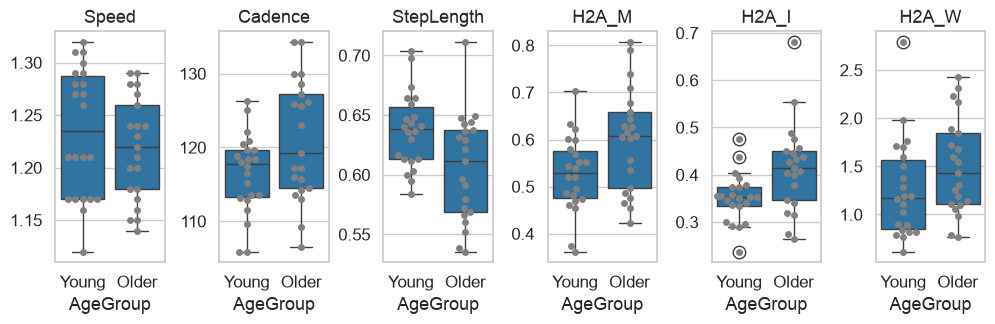

In [7]:
var = ['Age', 'Height', 'Mass', 'BMI', 'LegLength', 'Speed', 'StepLength', 'Cadence',
       'H2A_M', 'H2A_I', 'H2A_W']
describe(df, feature=var, group='AgeGroup');
boxplots(df)

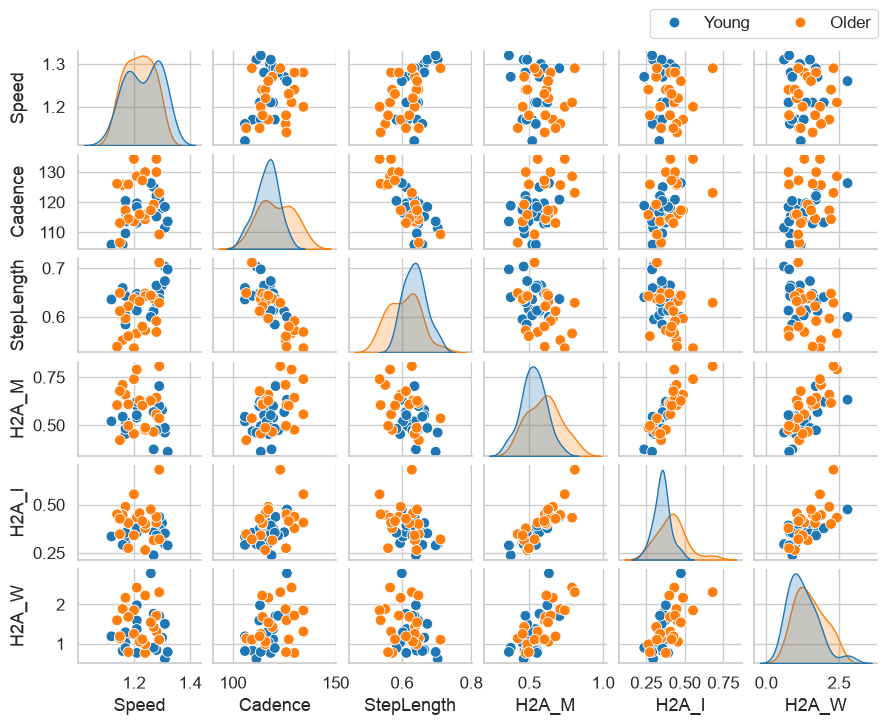

In [8]:
g = sns.pairplot(df, vars=['Speed', 'Cadence', 'StepLength', 'H2A_M', 'H2A_I', 'H2A_W'],
                 diag_kind='auto', hue='AgeGroup', plot_kws={'s':60}, height=1.2, aspect=1.1)
handles = g._legend_data.values()
labels = g._legend_data.keys()
g._legend.remove()
g.fig.legend(handles=handles, labels=labels, loc='upper right', ncol=2,
             bbox_to_anchor=(1, 1.02), bbox_transform=plt.gcf().transFigure)
g.fig.subplots_adjust(left=.1, right=.99, bottom = 0.1, top=.95, hspace=.1, wspace=.1)
g.fig.align_ylabels(g.axes[:, 0])
plt.show()

## Inferential statistics

### Correlation between variables

In [9]:
var = ['Speed', 'Cadence', 'StepLength', 'H2A_M', 'H2A_I', 'H2A_W']
corr = df[df['AgeGroup']=='Young'][var].rcorr(stars=True)
display(corr.style.set_caption('Correlation matrix for group Young'))
corr = df[df['AgeGroup']=='Older'][var].rcorr(stars=True)
display(corr.style.set_caption('Correlation matrix for group Older'))

,Speed,Cadence,StepLength,H2A_M,H2A_I,H2A_W
Speed,-,*,**,,,
Cadence,0.467,-,*,,*,*
StepLength,0.57,-0.455,-,,,
H2A_M,0.009,0.234,-0.213,-,***,**
H2A_I,0.107,0.447,-0.299,0.826,-,***
H2A_W,0.121,0.531,-0.352,0.583,0.66,-


,Speed,Cadence,StepLength,H2A_M,H2A_I,H2A_W
Speed,-,,,,,
Cadence,0.17,-,***,,,
StepLength,0.398,-0.833,-,,,
H2A_M,-0.008,0.363,-0.344,-,***,***
H2A_I,0.069,0.32,-0.267,0.821,-,**
H2A_W,0.015,0.162,-0.156,0.756,0.65,-


In [10]:
# A more detailed correlation table:
d = df[df['AgeGroup']=='Young'][var].pairwise_corr(method='pearson')
display(d.style.format({'p_unc': '{:.3f}'}).apply(sig_red, subset=['p_unc'])
        .set_caption('Pairwise correlation for group Young'))
d = df[df['AgeGroup']=='Older'][var].pairwise_corr(method='pearson')
display(d.style.format({'p_unc': '{:.3f}'}).apply(sig_red, subset=['p_unc'])
        .set_caption('Pairwise correlation for group Older'))

,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,Speed,Cadence,pearson,two-sided,22,0.466785,[0.06 0.74],0.029,2.517,0.613343
1,Speed,StepLength,pearson,two-sided,22,0.570457,[0.2 0.8],0.006,9.739,0.820904
2,Speed,H2A_M,pearson,two-sided,22,0.008927,[-0.41 0.43],0.969,0.264,0.049499
3,Speed,H2A_I,pearson,two-sided,22,0.106645,[-0.33 0.51],0.637,0.293,0.075631
4,Speed,H2A_W,pearson,two-sided,22,0.120949,[-0.32 0.52],0.592,0.302,0.083367
5,Cadence,StepLength,pearson,two-sided,22,-0.454501,[-0.74 -0.04],0.034,2.206,0.586601
6,Cadence,H2A_M,pearson,two-sided,22,0.234364,[-0.21 0.6 ],0.294,0.444,0.185123
7,Cadence,H2A_I,pearson,two-sided,22,0.446543,[0.03 0.73],0.037,2.032,0.569252
8,Cadence,H2A_W,pearson,two-sided,22,0.531048,[0.14 0.78],0.011,5.506,0.747945
9,StepLength,H2A_M,pearson,two-sided,22,-0.212893,[-0.58 0.23],0.341,0.405,0.160024


,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,Speed,Cadence,pearson,two-sided,21,0.170436,[-0.28 0.56],0.460,0.349,0.114976
1,Speed,StepLength,pearson,two-sided,21,0.398200,[-0.04 0.71],0.074,1.21,0.446170
2,Speed,H2A_M,pearson,two-sided,21,-0.008387,[-0.44 0.42],0.971,0.27,0.049441
3,Speed,H2A_I,pearson,two-sided,21,0.068528,[-0.37 0.49],0.768,0.282,0.059467
4,Speed,H2A_W,pearson,two-sided,21,0.014999,[-0.42 0.44],0.949,0.271,0.049773
5,Cadence,StepLength,pearson,two-sided,21,-0.833038,[-0.93 -0.63],0.000,7400.271,0.999324
6,Cadence,H2A_M,pearson,two-sided,21,0.363145,[-0.08 0.69],0.106,0.923,0.377206
7,Cadence,H2A_I,pearson,two-sided,21,0.320386,[-0.13 0.66],0.157,0.693,0.300742
8,Cadence,H2A_W,pearson,two-sided,21,0.162399,[-0.29 0.56],0.482,0.341,0.108675
9,StepLength,H2A_M,pearson,two-sided,21,-0.344105,[-0.68 0.1 ],0.127,0.808,0.342009


### Test for difference between groups' characteristics

In [11]:
var = ['Age', 'Height', 'Mass', 'BMI', 'LegLength']
stats = ttest(df, var, 'AgeGroup', levels=['Older', 'Young'])

,T,dof,p_val,CI95,cohen_d,%diff
Older minus Young (signed d),,,,,,
Age,25.447390,40.196112,0.000,[33.26 39. ],7.780884,129.900000
Height,-2.349537,40.458112,0.024,[-0.14 -0.01],-0.717961,-4.500000
Mass,-0.755008,39.415278,0.455,[-10.22 4.66],-0.231181,-4.000000
BMI,0.911449,39.704846,0.368,[-1.19 3.15],0.276564,4.100000
LegLength,-1.215326,38.449386,0.232,[-0.07 0.02],-0.372640,-2.900000


### Test for difference between groups' spatio-temporal variables

In [12]:
var = ['Speed', 'Cadence', 'StepLength']
stats = ttest(df, var, 'AgeGroup', levels=['Older', 'Young'])

,T,dof,p_val,CI95,cohen_d,%diff
Older minus Young (signed d),,,,,,
Speed,-0.946575,39.936940,0.350,[-0.05 0.02],-0.287341,-1.300000
Cadence,2.148730,34.479791,0.039,[0.25 8.85],0.661667,3.900000
StepLength,-2.630706,35.760227,0.012,[-0.06 -0.01],-0.809062,-4.900000


### Test for difference between groups' joint torque and power variables

In [13]:
var = ['H2A_M', 'H2A_I', 'H2A_W']
stats = ttest(df, var, 'AgeGroup', levels=['Older', 'Young'])

,T,dof,p_val,CI95,cohen_d,%diff
Older minus Young (signed d),,,,,,
H2A_M,2.493084,36.919933,0.017,[0.01 0.13],0.765803,14.000000
H2A_I,2.730734,30.680484,0.010,[0.02 0.11],0.843864,18.200000
H2A_W,1.526810,40.974672,0.134,[-0.08 0.55],0.465546,18.700000


## Regression models

The predictors are Age (as categorical), cadence, step length.  
The response variables are H2A_M, H2A_I and H2A_W.

### Data standardization

Continuous predictors and outcomes are centered by their full-sample means and divided by their sample standard deviations (`ddof=1`). This expresses coefficients in SD units; it does **not** make distributions normal or enforce regression assumptions. Residual diagnostics are assessed separately. Age group is an unscaled categorical contrast (Young = 0, Older = 1).

In [14]:
dfraw = df.copy(deep=True)
var = ['Speed', 'Cadence', 'StepLength', 'H2A_M', 'H2A_I', 'H2A_W']
# Standardization (mean 0, variance 1)
df[var] = df[var].apply(lambda x: (x-x.mean())/x.std(ddof=1), axis=0)

#### Replace letters by numeric values because it's easier to identify the effect  
E.g.: {'Y': 0, 'O': 1} implies that if there is an effect of Age and its coefficient (slope) is positive, it means that the response increases for older subjects and decreases for young subjects. Internally the letters were replaced by numbers anyway but we didn't know the order.

In [15]:
df['AgeGroup'] = df['AgeGroup'].replace({'Young': 0, 'Older': 1}).astype(str)
df['Gender'] = df['Gender'].replace({'F': 0, 'M': 1}).astype(str)

### Age, Step Length and Cadence at similar absolute speeds

In [16]:
features = ['H2A_M', 'H2A_I', 'H2A_W']
labels   = ['H2A_M', 'H2A_I', 'H2A_W']

# We are testing if the effect of StepLength or Cadence changes DEPENDING on AgeGroup
predictors = [
    'C(AgeGroup)',
    'StepLength',
    'Cadence',
    'C(AgeGroup) + StepLength',
    'C(AgeGroup) + Cadence',
    'C(AgeGroup) * StepLength', # Moderation model 1: Age, StepLength, and Age x StepLength
    'C(AgeGroup) * Cadence',    # Moderation model 2: Age, Cadence, and Age x Cadence
    'C(AgeGroup) * StepLength + C(AgeGroup) * Cadence' # Full moderation model
]
# predictors = ['C(AgeGroup)',
#               'StepLength',
#               'Cadence',
#               'C(AgeGroup) + StepLength',
#               'C(AgeGroup) + Cadence',
#               'C(AgeGroup) + StepLength + Cadence',
#              ]

groups = df['Subject']

#names = ['C(AgeGroup)[T.1]', 'StepLength', 'Cadence']

# Updated names to capture the interaction terms generated by statsmodels
names = [
    'C(AgeGroup)[T.1]', 
    'StepLength', 
    'Cadence', 
    'C(AgeGroup)[T.1]:StepLength', # Interaction term name
    'C(AgeGroup)[T.1]:Cadence'     # Interaction term name
]

models, fit_ml, fit_re = runmodels(df, predictors, features, groups=None, names=names, mixed=False)

Model  1: H2A_M ~ C(AgeGroup); OLS.
Model  2: H2A_M ~ StepLength; OLS.
Model  3: H2A_M ~ Cadence; OLS.
Model  4: H2A_M ~ C(AgeGroup) + StepLength; OLS.
Model  5: H2A_M ~ C(AgeGroup) + Cadence; OLS.
Model  6: H2A_M ~ C(AgeGroup) * StepLength; OLS.
Model  7: H2A_M ~ C(AgeGroup) * Cadence; OLS.
Model  8: H2A_M ~ C(AgeGroup) * StepLength + C(AgeGroup) * Cadence; OLS.
Model  9: H2A_I ~ C(AgeGroup); OLS.
Model 10: H2A_I ~ StepLength; OLS.
Model 11: H2A_I ~ Cadence; OLS.
Model 12: H2A_I ~ C(AgeGroup) + StepLength; OLS.
Model 13: H2A_I ~ C(AgeGroup) + Cadence; OLS.
Model 14: H2A_I ~ C(AgeGroup) * StepLength; OLS.
Model 15: H2A_I ~ C(AgeGroup) * Cadence; OLS.
Model 16: H2A_I ~ C(AgeGroup) * StepLength + C(AgeGroup) * Cadence; OLS.
Model 17: H2A_W ~ C(AgeGroup); OLS.
Model 18: H2A_W ~ StepLength; OLS.
Model 19: H2A_W ~ Cadence; OLS.
Model 20: H2A_W ~ C(AgeGroup) + StepLength; OLS.
Model 21: H2A_W ~ C(AgeGroup) + Cadence; OLS.
Model 22: H2A_W ~ C(AgeGroup) * StepLength; OLS.
Model 23: H2A_W ~ C(A

In [17]:
#names = [['Age'], ['StepLength'], ['Cadence']]
# added interaction terms to the names list
names = [['Age'], ['StepLength'], ['Cadence'], ['C(AgeGroup)[T.1]:StepLength'], ['C(AgeGroup)[T.1]:Cadence']]
display_table(models, names, filename='h2a_age_spt_comfSpeed.csv')

### Plots of the linear regressions

In [18]:
df = dfraw.copy(deep=True)  # back to the non-standardized values

In [19]:
df['AgeGroup'] = df['AgeGroup'].replace({'0': 'Young', '1': 'Older'}).astype(str)

def scatter_plot(df, var):
    fig = px.scatter(df, x='StepLength', y=var, color='AgeGroup', trendline='ols',
                     hover_data=['Subject', 'StepLength', 'Cadence', 'SpeedComf'],
                     labels={'Speed':''}, width=800, height=300)
    fig.update_layout(margin=dict(l=50, r=20, t=20, b=0),
                      legend=dict(yanchor='top', y=0.95, xanchor='left', x=0.05))
    fig.show()
    fig = px.scatter(df, x='Cadence', y=var, color='AgeGroup', trendline='ols',
                     hover_data=['Subject', 'StepLength', 'Cadence', 'SpeedComf'],
                     width=800, height=300)
    fig.update_layout(margin=dict(l=50, r=20, t=10, b=40), showlegend=False)
    fig.show()

In [20]:
scatter_plot(df, 'H2A_M')

In [21]:
scatter_plot(df, 'H2A_I')

In [22]:
scatter_plot(df, 'H2A_W')

## Three-dimensional plots: Step Length and Cadence versus Speed

In [23]:
cadence_label = 'Cadence [steps/s]' if df['Cadence'].mean() < 10 else 'Cadence [steps/min]'
# add plane: https://memotut.com/en/e42c726cdee25767105d/
df['AgeGroup'] = df['AgeGroup'].replace({0: 'Young', 1: 'Older'}).astype(str)
fig = px.scatter_3d(df, x='StepLength', y='Cadence', z='Speed', color='AgeGroup',
                    labels={'StepLength': 'Step Length [m]', 'Cadence': cadence_label,
                            'Speed': 'Speed [m/s]'},
                    width=800, height=600)
fig.update_traces(marker=dict(size=5), selector=dict(mode='markers'))
camera = dict(up=dict(x=0, y=0, z=1), center=dict(x=0, y=0, z=0), eye=dict(x=1, y=-2, z=0.5))
fig.update_layout(scene_camera=camera)
fig.show()

## Revision analyses: adjustment, interactions, and indirect associations

All models use one selected V4, V5, or V6 trial for each of 43 independent participants at similar absolute speeds (1.12–1.32 m/s), not necessarily each participant's preferred speed. The exact upstream selection rule remains pending verification. Continuous variables use sample SD scaling (`ddof=1`); AgeGroup and Female are unscaled 0/1 variables. The analyses below supplement the 24 primary models. Estimates, confidence intervals, and p values are exploratory and unadjusted for multiple comparisons. A non-significant adjusted age coefficient is not evidence that the age association vanished.

In [24]:
sys.path.insert(0, str(ROOT / 'notebooks'))
from revision_analysis import experiment2
revision_exp2 = experiment2()
display(revision_exp2['sensitivity'])

,model,outcome,sample,term,estimate,se,ci_low,ci_high,p,n,r2,llf,aic,formula
0,age_sex,H2A_M,full,Intercept,-0.136,0.219,-0.579,0.306,0.536,43,0.219,-55.189,116.379,H2A_M ~ AgeGroup + Female
1,age_sex,H2A_M,full,AgeGroup,0.760,0.277,0.201,1.320,0.009,43,0.219,-55.189,116.379,H2A_M ~ AgeGroup + Female
2,age_sex,H2A_M,full,Female,-0.594,0.283,-1.166,-0.022,0.042,43,0.219,-55.189,116.379,H2A_M ~ AgeGroup + Female
3,cadence_sex,H2A_M,full,Intercept,0.072,0.211,-0.354,0.498,0.734,43,0.369,-50.607,109.215,H2A_M ~ AgeGroup + Cadence + Female
4,cadence_sex,H2A_M,full,AgeGroup,0.505,0.266,-0.032,1.043,0.064,43,0.369,-50.607,109.215,H2A_M ~ AgeGroup + Cadence + Female
5,cadence_sex,H2A_M,full,Cadence,0.424,0.139,0.142,0.705,0.004,43,0.369,-50.607,109.215,H2A_M ~ AgeGroup + Cadence + Female
6,cadence_sex,H2A_M,full,Female,-0.807,0.267,-1.347,-0.267,0.004,43,0.369,-50.607,109.215,H2A_M ~ AgeGroup + Cadence + Female
7,step_length_sex,H2A_M,full,Intercept,0.112,0.216,-0.325,0.550,0.607,43,0.365,-50.733,109.467,H2A_M ~ AgeGroup + StepLength + Female
8,step_length_sex,H2A_M,full,AgeGroup,0.448,0.273,-0.105,1.001,0.109,43,0.365,-50.733,109.467,H2A_M ~ AgeGroup + StepLength + Female
9,step_length_sex,H2A_M,full,StepLength,-0.434,0.145,-0.726,-0.141,0.005,43,0.365,-50.733,109.467,H2A_M ~ AgeGroup + StepLength + Female


Cadence adjustment reduces the age coefficients for H2A_M from 0.722 to 0.523 (95% CI −0.066 to 1.112), and for H2A_I from 0.784 to 0.567 (−0.006 to 1.139), about 28% attenuation. These adjusted intervals include zero and the unadjusted point estimates. Adding sex increases H2A_M model R² from .221 to .369. The H2A_I age estimate is 0.552; its classical 95% CI [0.014, 1.090] changes to [−0.016, 1.120] with HC3 t inference below. This threshold sensitivity warrants reporting estimates and uncertainty rather than declaring the age association absent or restored. Similar sex counts across age groups do not justify dismissing sex as a covariate.

### Interaction uncertainty and descriptive sensitivity

The six separate AgeGroup × StepLength or AgeGroup × Cadence terms are shown first; the joint interaction model remains available in the exported table. Approximate minimum detectable effects (80% power, two-sided α = .05) use the observed standard error multiplied by $t_{.975,df}+z_{.80}$. These are descriptive sensitivity calculations conditional on this design and variance estimate, not retrospective evidence for the null or a prospective sample-size justification.

In [25]:
isolated_interactions = revision_exp2['interactions'].query('model in [6, 7, 14, 15, 22, 23]')
assert len(isolated_interactions) == 6
display(isolated_interactions)
display(revision_exp2['vif'])
print('Cadence–step length correlation:', pd.read_csv(ROOT / 'results/sample_statistics.csv').cadence_step_length_r.iloc[0])

,model,outcome,term,estimate,se,ci_low,ci_high,p,approximate_mde80
0,6,H2A_M,AgeGroup:StepLength,-0.117,0.324,-0.773,0.538,0.719,0.929
1,7,H2A_M,AgeGroup:Cadence,0.094,0.321,-0.555,0.743,0.771,0.919
4,14,H2A_I,AgeGroup:StepLength,-0.037,0.322,-0.690,0.615,0.908,0.924
5,15,H2A_I,AgeGroup:Cadence,-0.050,0.312,-0.682,0.582,0.874,0.895
8,22,H2A_W,AgeGroup:StepLength,0.320,0.342,-0.371,1.010,0.355,0.978
9,23,H2A_W,AgeGroup:Cadence,-0.564,0.324,-1.220,0.092,0.090,0.929


,outcome,term,vif
0,H2A_M,AgeGroup,1.176
1,H2A_M,StepLength,2.352
2,H2A_M,Cadence,2.238
3,H2A_I,AgeGroup,1.176
4,H2A_I,StepLength,2.352
5,H2A_I,Cadence,2.238
6,H2A_W,AgeGroup,1.176
7,H2A_W,StepLength,2.352
8,H2A_W,Cadence,2.238


Cadence–step length correlation: -0.742694710693


The separate interaction confidence intervals are wide, with approximate detectable slope differences of 0.895–0.978 outcome SD per predictor SD. Non-significant interaction tests therefore do not establish absence of moderation. Cadence and step length are strongly negatively correlated (r = −.743), limiting their independent interpretation in the joint model.

### Paired-subject bootstrap: percentile primary, BCa sensitivity

The product $ab$ is an exploratory indirect **association**: $a$ is the AgeGroup coefficient in the spatiotemporal model, and $b$ is that parameter's coefficient in the age-adjusted outcome model. Entire subject rows are resampled together 10,000 times, with fixed full-sample scaling and seed 20260910. Percentile 95% intervals are primary; bias-corrected and accelerated (BCa) intervals are reported as a sensitivity analysis. Bootstrap tail proportions are not reported as null-test p values. Attenuation percentages describe coefficient decomposition, not proportions causally mediated. Cross-sectional data and unmeasured common causes (including muscle strength) prevent a causal mediation interpretation.

In [26]:
assert revision_exp2['indirect'].n_boot.eq(10000).all()
display(revision_exp2['indirect'])

,mediator,outcome,sex_adjusted,a,b,total,direct,indirect,percentile_low,percentile_high,bca_low,bca_high,z0,acceleration,attenuation_pct,n_boot,seed
0,Cadence,H2A_M,False,0.634,0.313,0.722,0.523,0.199,-0.011,0.454,0.031,0.552,0.220,1.390e-02,27.539,10000,20260910
1,Cadence,H2A_I,False,0.634,0.343,0.784,0.567,0.218,0.014,0.479,0.053,0.583,0.201,2.319e-02,27.746,10000,20260910
2,Cadence,H2A_W,False,0.634,0.317,0.458,0.257,0.201,-0.021,0.479,0.030,0.603,0.244,1.172e-02,43.839,10000,20260910
3,StepLength,H2A_M,False,-0.757,-0.300,0.722,0.495,0.227,-0.004,0.594,0.020,0.668,0.124,1.030e-02,31.424,10000,20260910
4,StepLength,H2A_I,False,-0.757,-0.273,0.784,0.578,0.207,-0.044,0.508,0.007,0.602,0.178,7.792e-03,26.338,10000,20260910
5,StepLength,H2A_W,False,-0.757,-0.249,0.458,0.270,0.188,-0.044,0.543,-0.009,0.624,0.145,2.640e-03,41.054,10000,20260910
6,Cadence,H2A_M,True,0.602,0.424,0.760,0.505,0.255,0.018,0.552,0.044,0.611,0.129,7.053e-03,33.520,10000,20260910
7,Cadence,H2A_I,True,0.602,0.435,0.814,0.552,0.262,0.021,0.592,0.040,0.633,0.111,-7.341e-03,32.180,10000,20260910
8,Cadence,H2A_W,True,0.602,0.365,0.469,0.250,0.219,0.006,0.543,0.030,0.635,0.169,-4.788e-04,46.753,10000,20260910
9,StepLength,H2A_M,True,-0.720,-0.434,0.760,0.448,0.312,0.038,0.719,0.051,0.746,0.072,-5.539e-03,41.087,10000,20260910


Without sex adjustment, the cadence–H2A_I indirect association is 0.218, with percentile 95% CI [0.014, 0.479]. The other five unadjusted percentile intervals include zero. Five of six unadjusted BCa intervals exclude zero, demonstrating sensitivity to interval construction. With sex adjustment, five of six percentile intervals exclude zero, including all three cadence paths; these are exploratory, model-dependent associations and do not show that cadence causes redistribution or eliminates the age association.

### Residual diagnostics for the principal adjusted models

Residual-versus-fitted and normal Q–Q plots below examine the AgeGroup + Cadence and AgeGroup + Cadence + Female models for all three outcomes. The impulse outcome shows a right-tail departure, especially for Subject 35. Visual checks do not certify model assumptions; these observations motivate caution about small-sample inference. No additional participants are excluded.

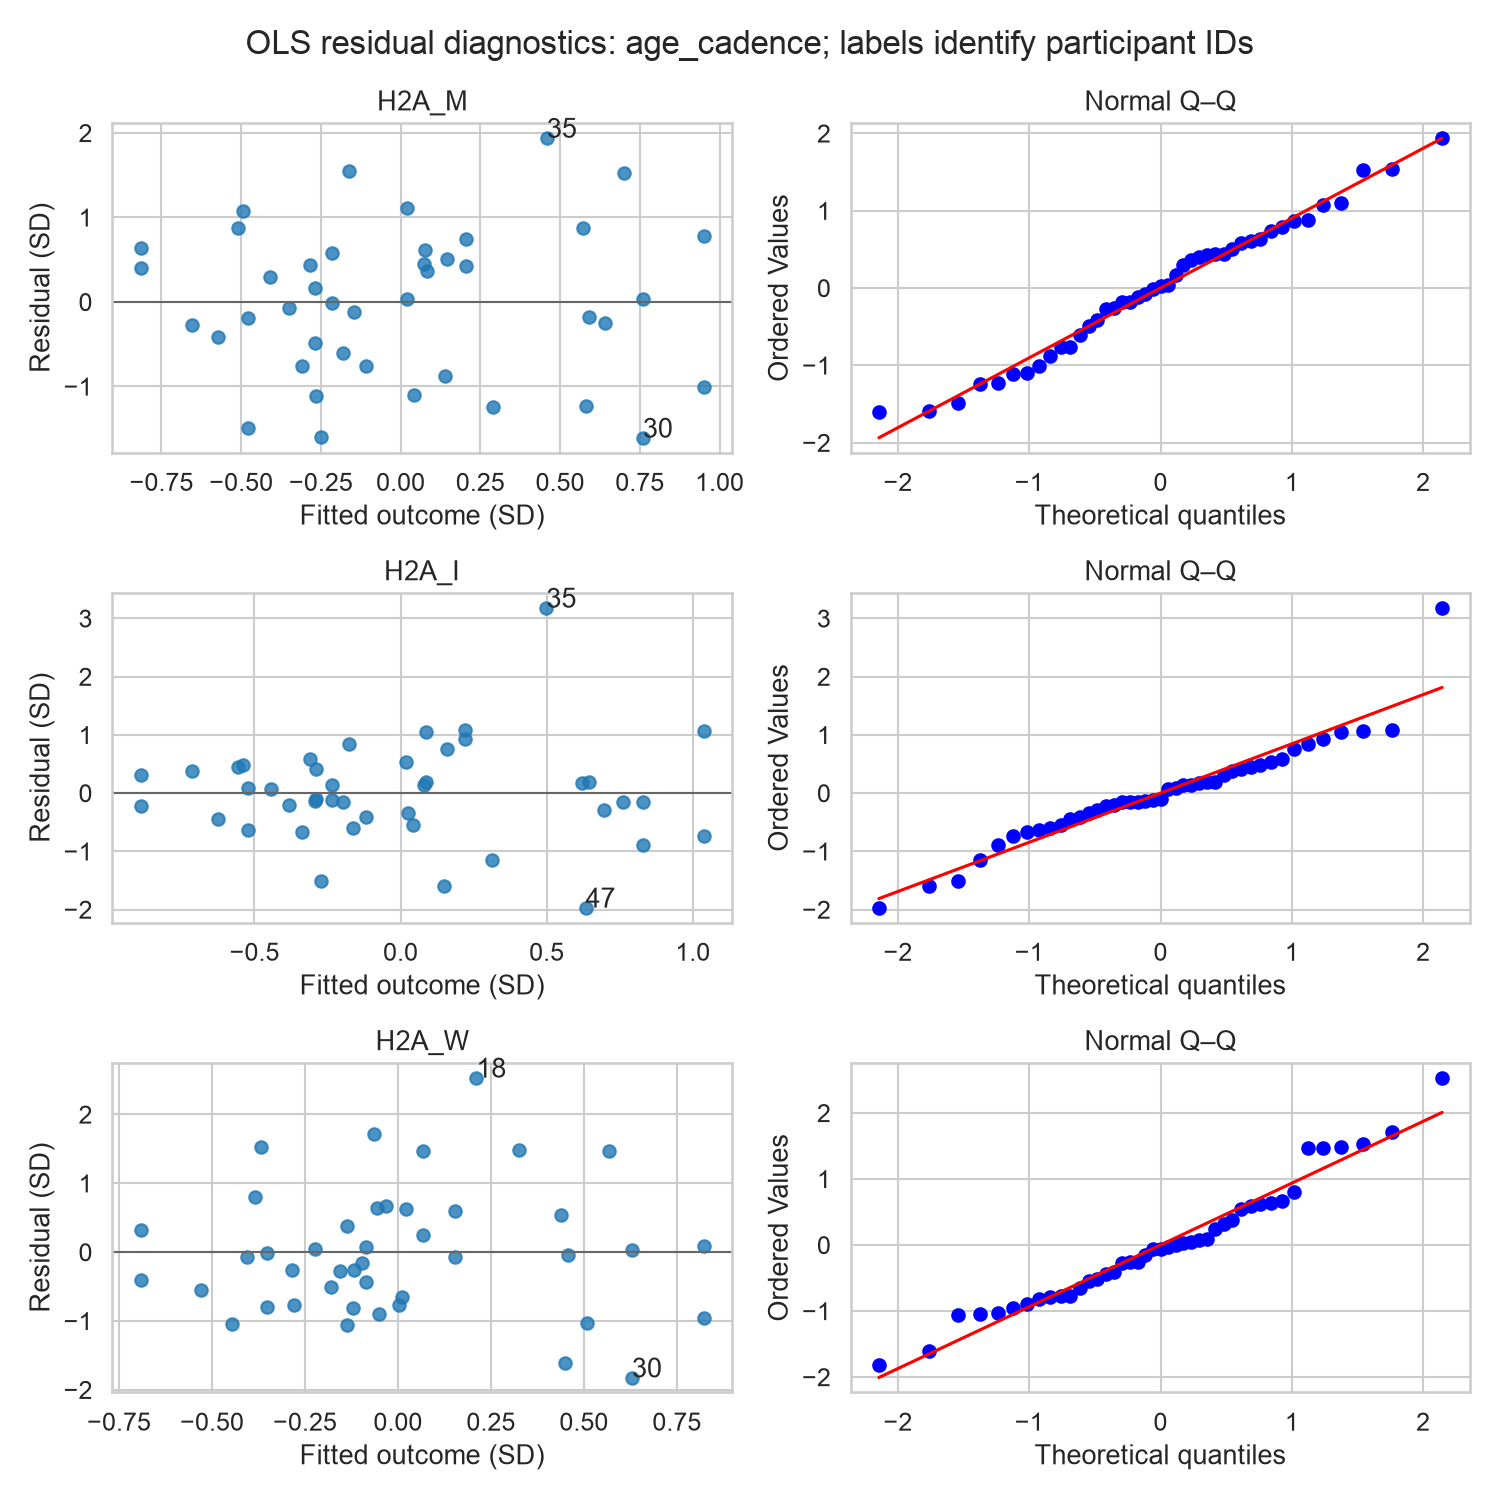

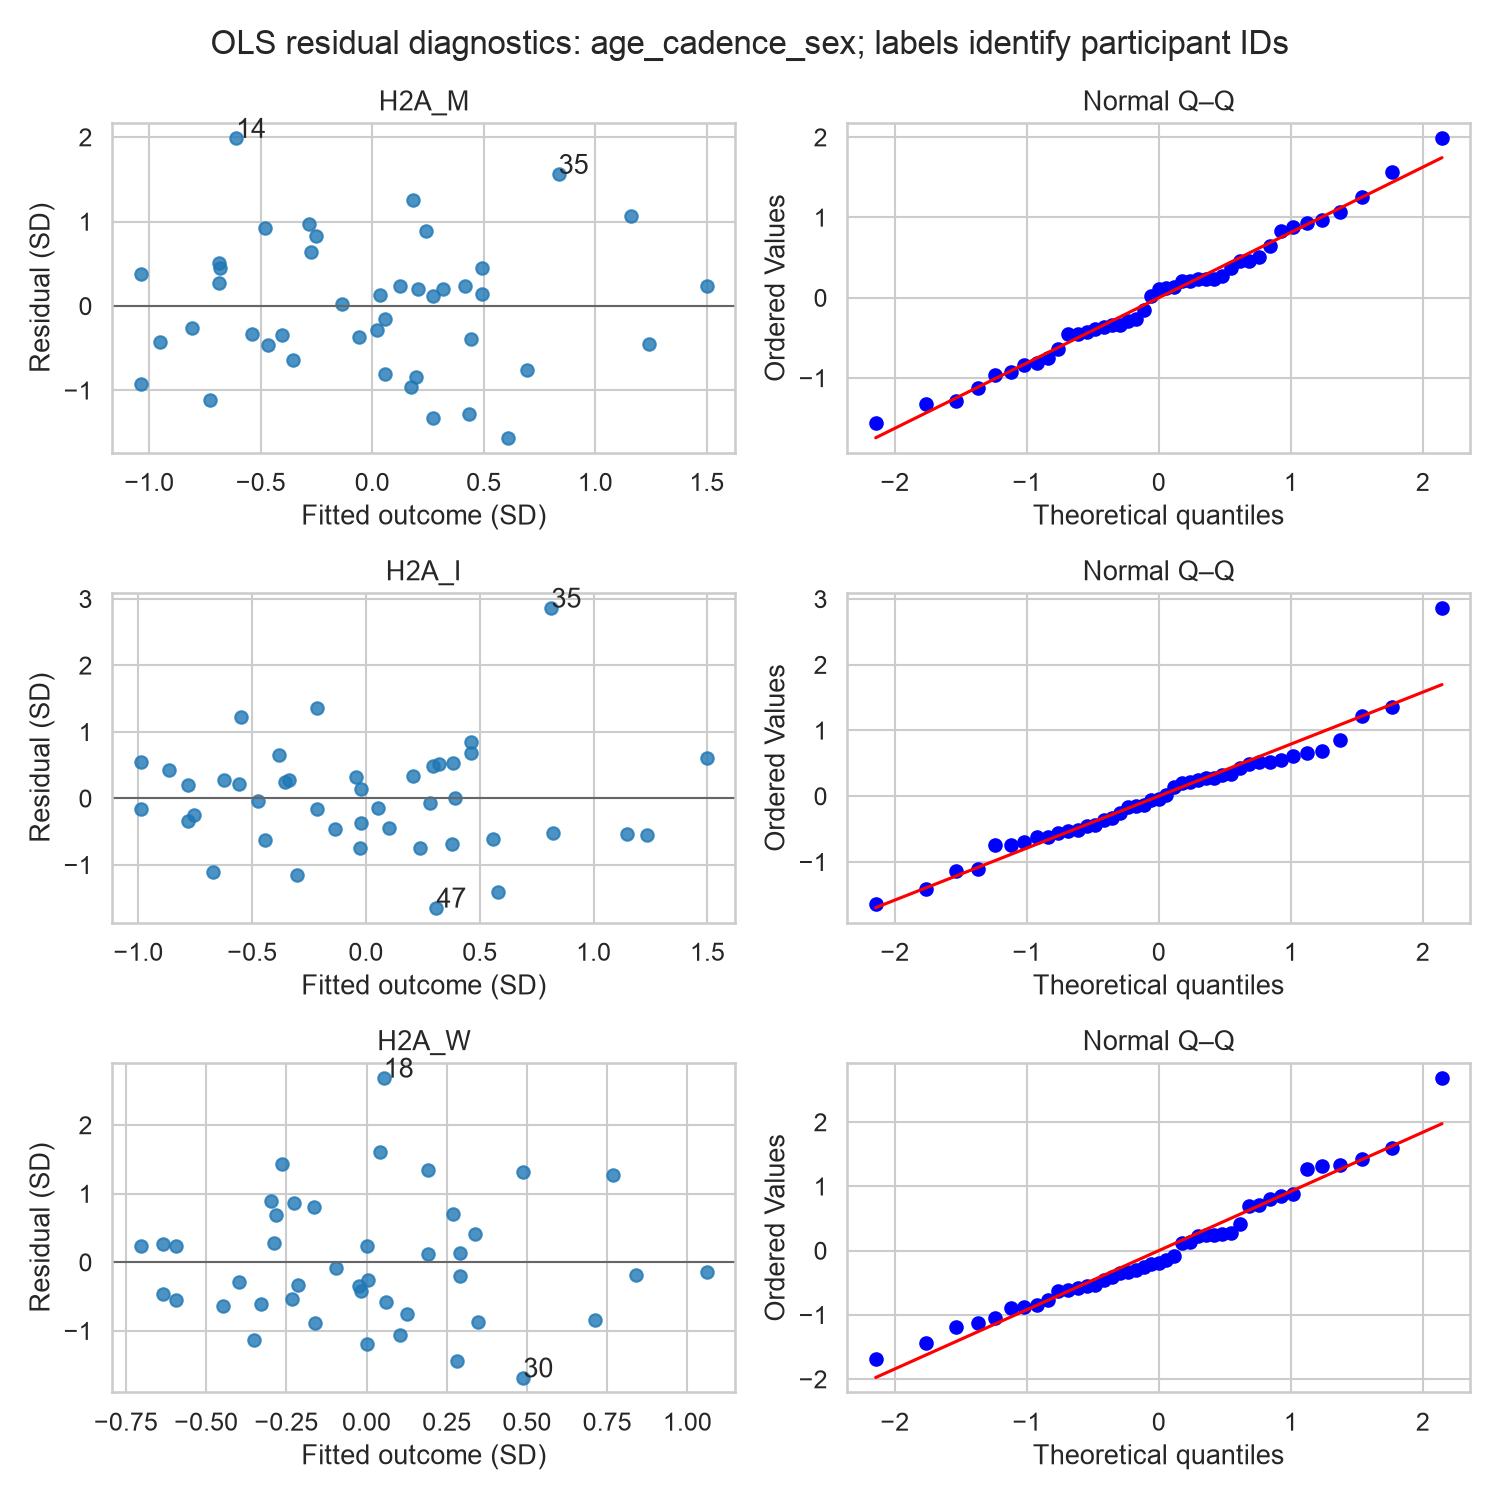

In [27]:
sys.path.insert(0, str(ROOT / 'scripts'))
from diagnostics import make_diagnostics
from IPython.display import Image, display
for diagnostic_path in make_diagnostics():
    display(Image(filename=str(diagnostic_path)))

### HC3, height, and relative-speed sensitivity

The age + cadence + sex model is refitted with HC3 covariance and explicit Student t inference (`use_t=True`, 39 residual degrees of freedom). HC3 changes standard errors and intervals, not coefficients or R²; it does not correct every possible model violation. Separate classical-covariance models add height or relative speed (selected-trial Speed/SpeedComf) to assess these alternative adjustments. Each continuous covariate uses full-sample sample-SD scaling. These are exploratory sensitivities, with no multiplicity adjustment.

In [28]:
followup_columns = ['model', 'outcome', 'term', 'estimate', 'ci_low', 'ci_high', 'p', 'r2']
followup_models = ['cadence_sex_classical', 'cadence_sex_hc3', 'cadence_sex_height', 'cadence_sex_relative_speed']
covariate_sensitivity = revision_exp2['followup'].loc[
    revision_exp2['followup'].model.isin(followup_models) &
    ~revision_exp2['followup'].term.eq('Intercept')]
with pd.option_context('display.max_rows', None):
    display(covariate_sensitivity[followup_columns])
print('Height and relative speed by age group, before z scoring')
display(revision_exp2['normalized_descriptive'].query("variable in ['Height', 'RelativeSpeed']")[['variable', 'young_mean', 'young_sd', 'older_mean', 'older_sd', 'difference', 'ci_low', 'ci_high', 'p']])

,model,outcome,term,estimate,ci_low,ci_high,p,r2
1,cadence_sex_classical,H2A_M,AgeGroup,0.505,-0.032,1.043,0.064,0.369
2,cadence_sex_classical,H2A_M,Cadence,0.424,0.142,0.705,0.004,0.369
3,cadence_sex_classical,H2A_M,Female,-0.807,-1.347,-0.267,0.004,0.369
5,cadence_sex_hc3,H2A_M,AgeGroup,0.505,-0.056,1.067,0.076,0.369
6,cadence_sex_hc3,H2A_M,Cadence,0.424,0.174,0.673,0.001,0.369
7,cadence_sex_hc3,H2A_M,Female,-0.807,-1.384,-0.230,0.007,0.369
9,cadence_sex_height,H2A_M,AgeGroup,0.496,-0.079,1.071,0.089,0.369
10,cadence_sex_height,H2A_M,Cadence,0.418,0.112,0.724,0.009,0.369
11,cadence_sex_height,H2A_M,Female,-0.833,-1.590,-0.077,0.032,0.369
12,cadence_sex_height,H2A_M,Height,-0.022,-0.447,0.404,0.919,0.369


Height and relative speed by age group, before z scoring


,variable,young_mean,young_sd,older_mean,older_sd,difference,ci_low,ci_high,p
3,RelativeSpeed,1.014,0.112,0.971,0.122,-0.042,-0.115,0.030,0.245
5,Height,1.720,0.104,1.643,0.111,-0.077,-0.143,-0.011,0.024


Under HC3 t inference, the H2A_I age coefficient is 0.552 [−0.016, 1.120], p = .0567, compared with classical p = .0448. Cadence remains positively estimated, with HC3 intervals [0.174, 0.673], [0.181, 0.690], and [0.054, 0.675] for H2A_M, H2A_I, and H2A_W. Adding height or relative speed separately gives H2A_I age estimates of 0.452 [−0.116, 1.019] and 0.467 [−0.086, 1.020]. The estimates remain compatible with a range of residual age associations.

Mean relative speed is 1.014 in young and 0.971 in older participants (older-minus-young difference −0.0423, Welch 95% CI [−0.115, 0.0301]). Similar absolute selected speeds should not be interpreted as identical relative effort or identical fractions of preferred speed.

### Hof-normalized parameters and age-coefficient attenuation

Dimensionless step length is StepLength/LegLength. Dimensionless cadence is (Cadence/60)$\sqrt{\mathrm{LegLength}/9.81}$, with source cadence in steps/minute and leg length in metres. These normalized parameters are then z scored using their full-sample sample SD before substitution in the age-adjusted OLS models. Outcomes retain their original SD scaling, allowing age-coefficient attenuation to be compared with the prior models. Sex-adjusted models are compared with age + sex reference models. Welch comparisons below use normalized values before z scoring.

This selected-trial analysis does not impose equal dimensionless speed. Normalization changes the predictor definition, and attenuation remains a statistical decomposition rather than a causal mediated proportion.

In [29]:
print('Normalized spatiotemporal descriptives at selected trials')
display(revision_exp2['normalized_descriptive'].query("variable in ['StepLengthHof', 'CadenceHof', 'SpeedHof']")[['variable', 'young_mean', 'young_sd', 'older_mean', 'older_sd', 'difference', 'ci_low', 'ci_high', 'p']])
normalized_models = revision_exp2['followup'].loc[
    revision_exp2['followup'].model.str.contains('Hof') &
    ~revision_exp2['followup'].term.eq('Intercept')]
with pd.option_context('display.max_rows', None):
    display(normalized_models[followup_columns])
display(revision_exp2['hof_attenuation'][['outcome', 'predictor', 'sex_adjusted', 'age_reference', 'age_adjusted', 'attenuation_pct', 'age_adjusted_ci_low', 'age_adjusted_ci_high']])

Normalized spatiotemporal descriptives at selected trials


,variable,young_mean,young_sd,older_mean,older_sd,difference,ci_low,ci_high,p
0,StepLengthHof,0.724,0.041,0.710,0.053,-1.454e-02,-0.044,0.015,0.319
1,CadenceHof,0.581,0.022,0.595,0.037,1.359e-02,-0.006,0.033,0.158
2,SpeedHof,0.420,0.025,0.421,0.020,8.292e-04,-0.013,0.015,0.903


,model,outcome,term,estimate,ci_low,ci_high,p,r2
19,CadenceHof,H2A_M,AgeGroup,0.544,-0.003,1.091,0.051,0.288
20,CadenceHof,H2A_M,CadenceHof,0.404,0.127,0.680,0.005,0.288
22,StepLengthHof,H2A_M,AgeGroup,0.606,0.059,1.154,0.031,0.268
23,StepLengthHof,H2A_M,StepLengthHof,-0.372,-0.648,-0.095,0.010,0.268
25,CadenceHof_sex,H2A_M,AgeGroup,0.592,0.057,1.126,0.031,0.344
26,CadenceHof_sex,H2A_M,CadenceHof,0.367,0.095,0.639,0.010,0.344
27,CadenceHof_sex,H2A_M,Female,-0.484,-1.022,0.054,0.076,0.344
29,StepLengthHof_sex,H2A_M,AgeGroup,0.651,0.099,1.203,0.022,0.291
30,StepLengthHof_sex,H2A_M,StepLengthHof,-0.299,-0.605,0.006,0.054,0.291
31,StepLengthHof_sex,H2A_M,Female,-0.338,-0.949,0.273,0.270,0.291


,outcome,predictor,sex_adjusted,age_reference,age_adjusted,attenuation_pct,age_adjusted_ci_low,age_adjusted_ci_high
0,H2A_M,CadenceHof,False,0.722,0.544,24.639,-0.003,1.091
1,H2A_M,StepLengthHof,False,0.722,0.606,15.956,0.059,1.154
2,H2A_M,CadenceHof,True,0.760,0.592,22.174,0.057,1.126
3,H2A_M,StepLengthHof,True,0.760,0.651,14.388,0.099,1.203
4,H2A_I,CadenceHof,False,0.784,0.651,16.941,0.088,1.215
5,H2A_I,StepLengthHof,False,0.784,0.744,5.109,0.162,1.326
6,H2A_I,CadenceHof,True,0.814,0.688,15.419,0.127,1.249
7,H2A_I,StepLengthHof,True,0.814,0.799,1.752,0.217,1.382
8,H2A_W,CadenceHof,False,0.458,0.297,35.225,-0.289,0.883
9,H2A_W,StepLengthHof,False,0.458,0.385,16.029,-0.219,0.989


Normalized step length and cadence have older-minus-young differences −0.0145 (95% CI −0.0437 to 0.0146) and +0.0136 (−0.00555 to 0.0327). For H2A_I, normalized cadence adjustment attenuates the unadjusted age coefficient by 16.9%; normalized step length attenuates it by 5.1%. With sex adjustment, the corresponding attenuation is 15.4% and 1.8%. The age coefficient with normalized cadence and sex remains 0.688 [0.127, 1.249], while the normalized-cadence coefficient is 0.273 [−0.013, 0.559]. These parameterization-dependent results limit a broad claim that spatiotemporal parameters account for the age association.

## References
 - P. DeVita, T. Hortobagyi, Age causes a redistribution of joint torques  and powers during gait, Journal of Applied Physiology. 88 (2000) 1804–1811. https://doi.org/10.1152/jappl.2000.88.5.1804.    
 - Y.P. Lim, Y.-C. Lin, M.G. Pandy, Muscle function during gait is invariant to age when walking speed is controlled, Gait Posture. 38 (2013) 253–259.   
 - C.A. Fukuchi, R.K. Fukuchi, M. Duarte, A public dataset of overground and treadmill walking kinematics and kinetics in healthy individuals, PeerJ. 6 (2018) e4640. https://doi.org/10.7717/peerj.4640.  